# Analyze Baselines

In [1]:
from pathlib import Path
import json

import pandas as pd

In [2]:
from temp import (
    temp_metrics,
    plot_temp_consistency,
)

## Load Original Flows

In [3]:
dataset = "aitv2"
scenario = "santos"

In [4]:
# Configuration
test_scenario = "santos"
attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

out_dir = Path(f"../reports/{dataset}/{scenario}/baselines")
out_dir.mkdir(parents=True, exist_ok=True)

In [5]:
# Cross-scenario config
# scenario = "santos_fox"
# test_scenario = "fox"

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

In [6]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{test_scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [7]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [8]:
phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


## Temp Plots and Custom Metrics

In [9]:
models = [
    "multiclass",
    # "ensemble",
]

file_paths = []

for model in models:
    folder = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics/")
    file_paths.extend(list(folder.iterdir()))

print(len(file_paths))

12


Processing multiclass_reduced_w10_full...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_reduced_w10_full.png...
Processing multiclass_reduced_w10_balanced...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_reduced_w10_balanced.png...
Processing multiclass_reduced_w100_full...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_reduced_w100_full.png...
Processing multiclass_full_w100_balanced...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_full_w100_balanced.png...
Processing multiclass_reduced_w100_balanced...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_reduced_w100_balanced.png...
Processing multiclass_aug_w100_full...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_aug_w100_full.png...
Processing multiclass_full_w10_balanced...
Saving plot to ../reports/aitv2/santos/baselines/temp_plots/multiclass_full_w10_balanced.png...
Processing multiclass

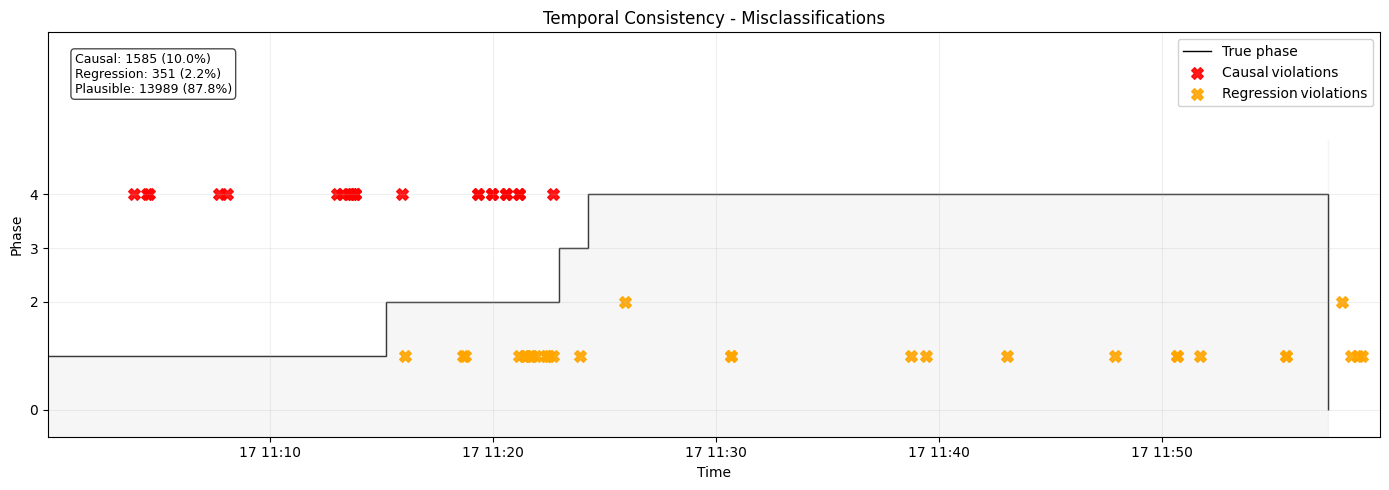

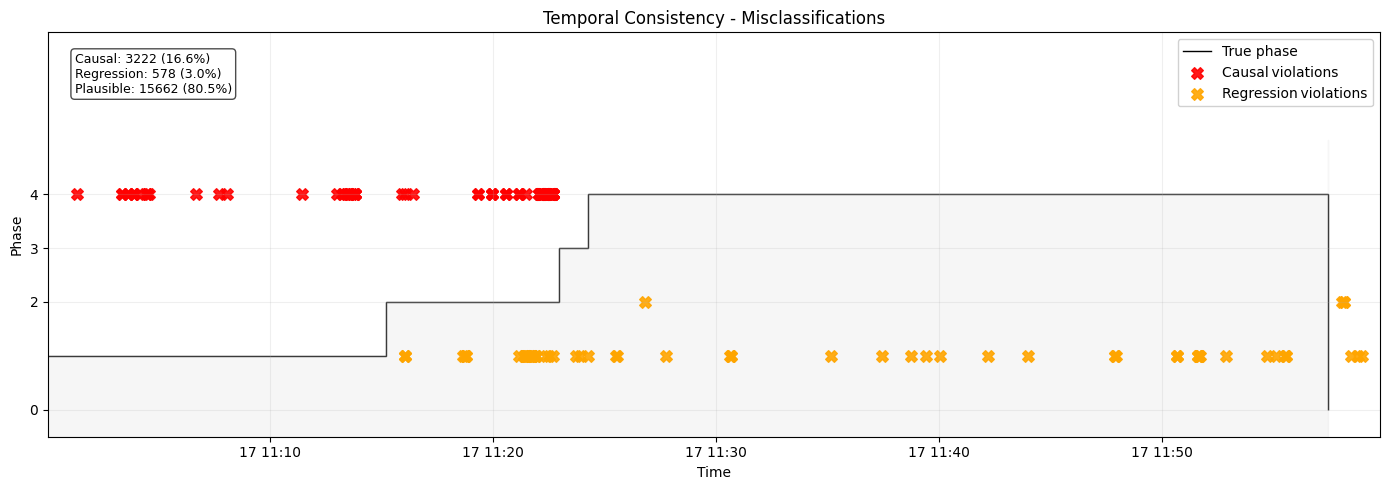

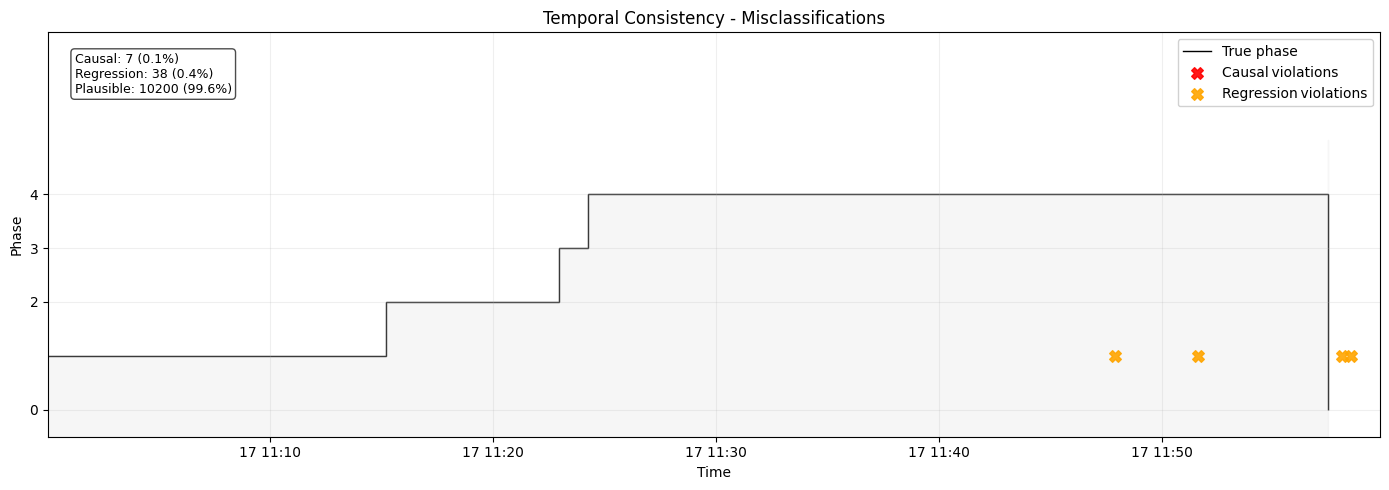

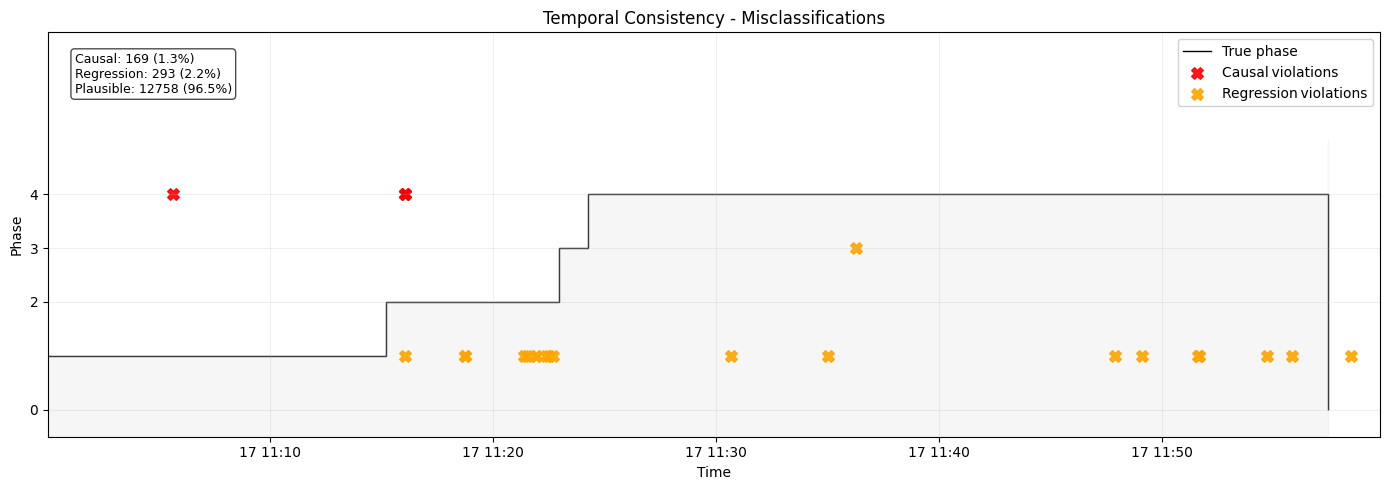

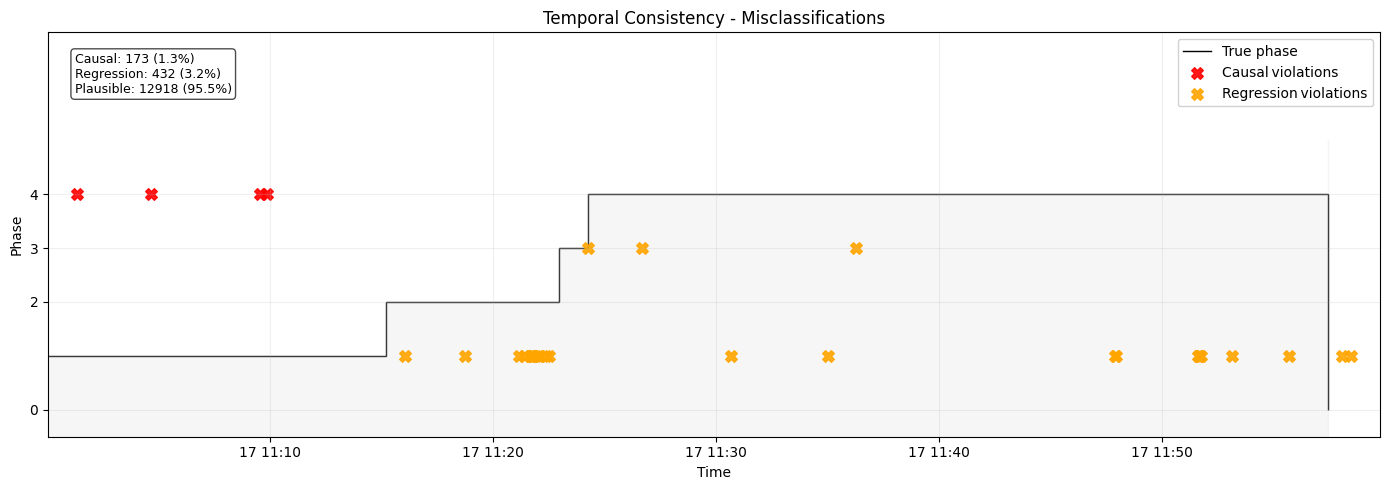

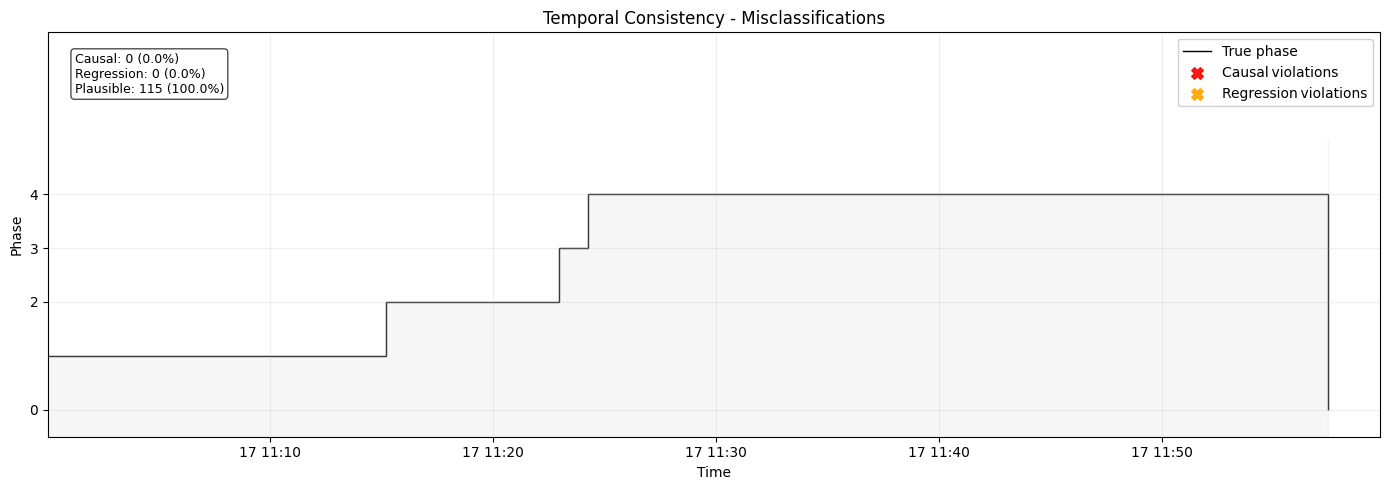

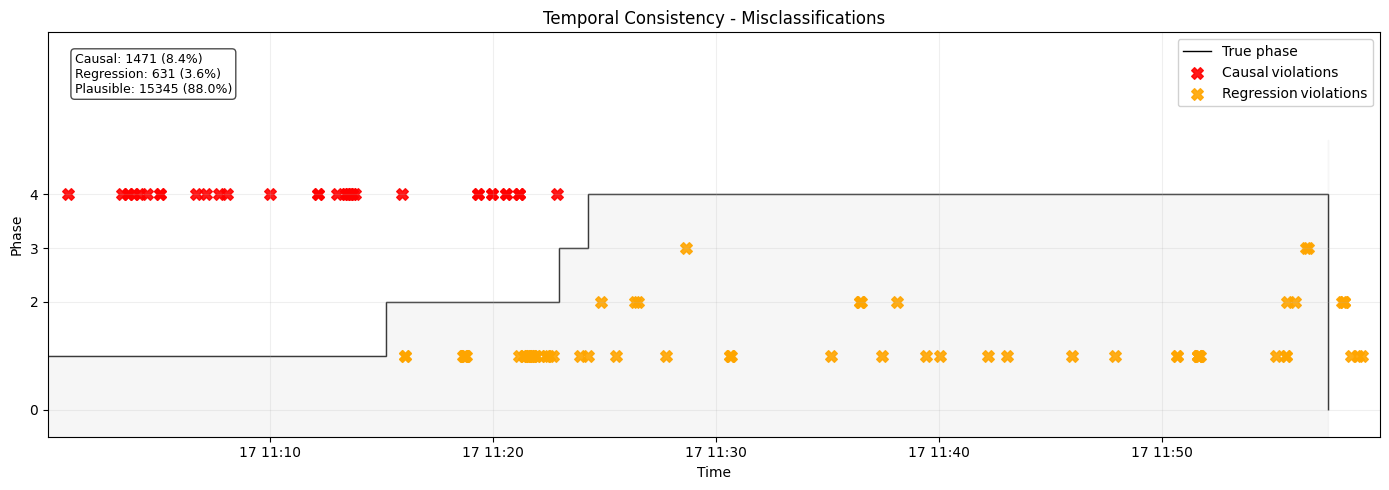

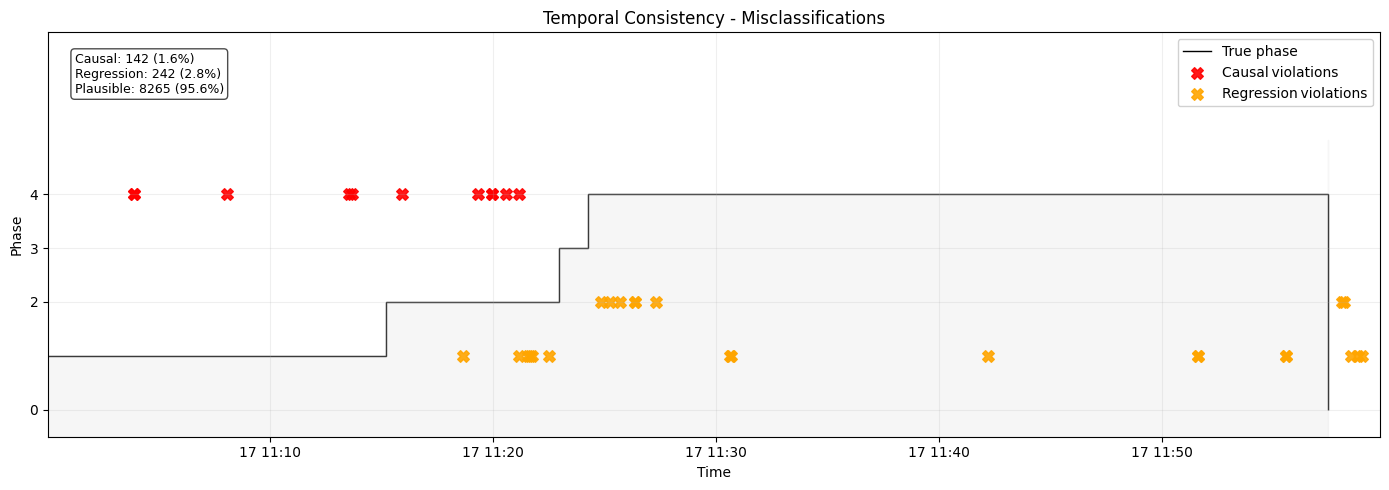

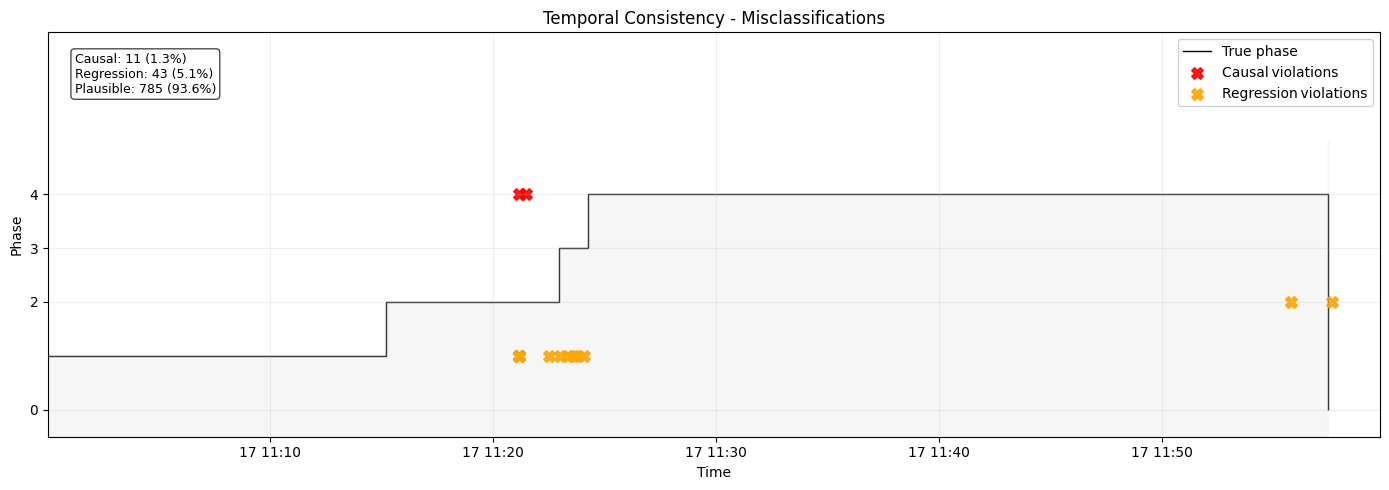

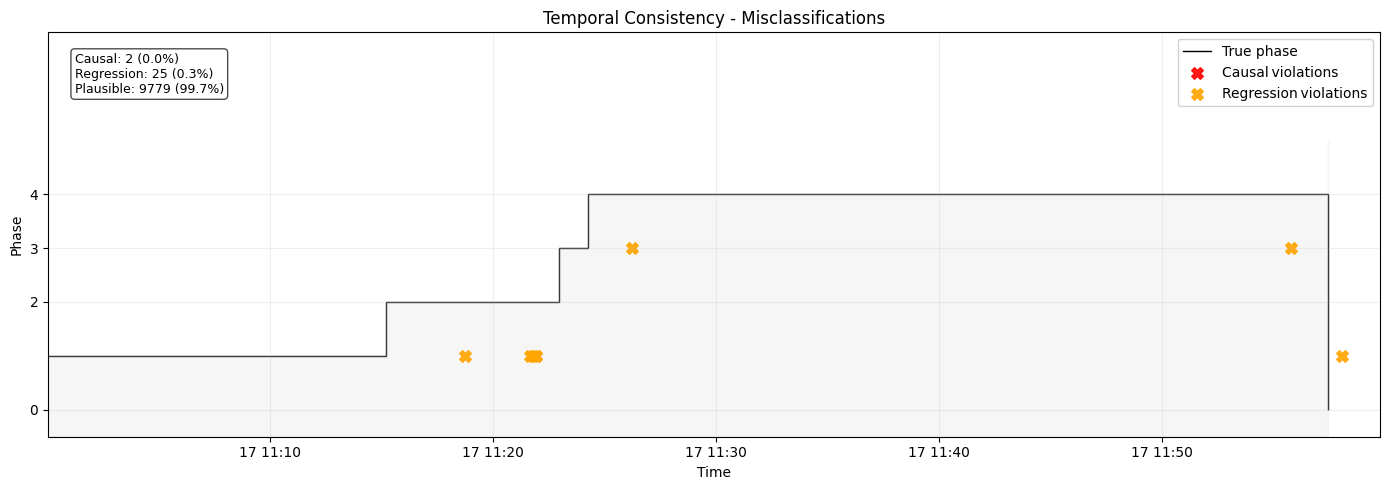

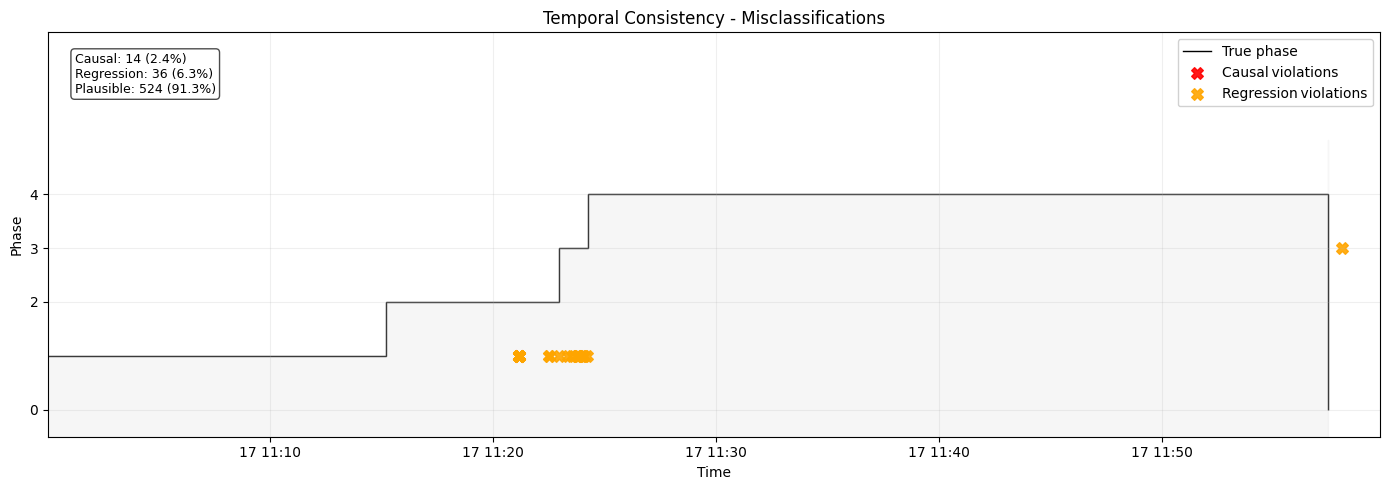

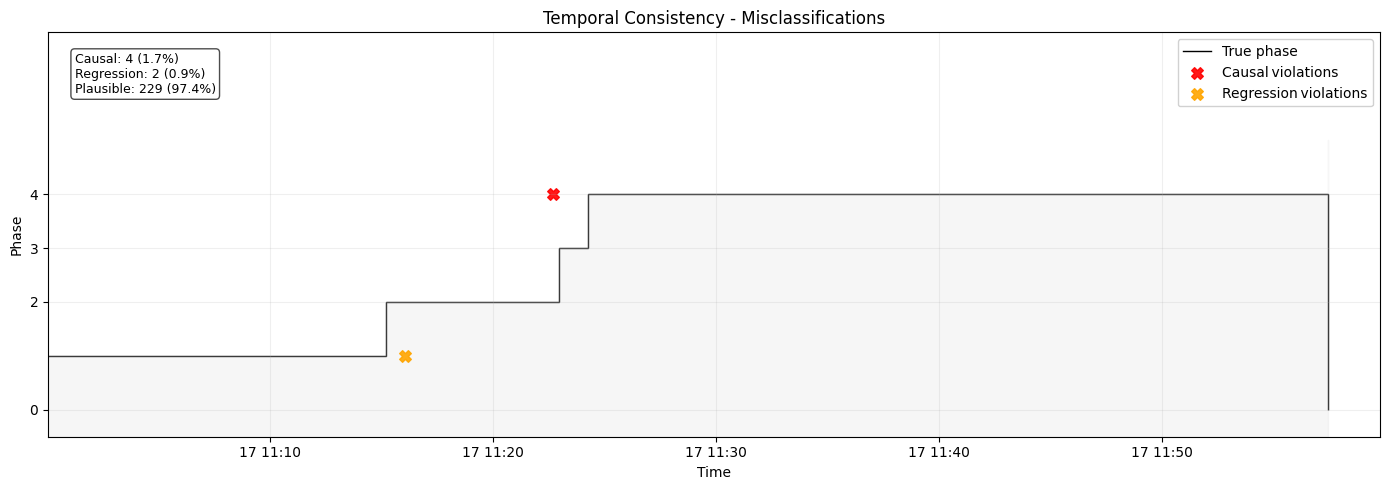

In [10]:
results = []

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem

    if "multiclass" in experiment_name:
        model = "multiclass"
    elif "ensemble" in experiment_name:
        model = "ensemble"

    print(f"Processing {experiment_name}...")

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    misclassified = df.iloc[real_flow_indices].copy()
    misclassified["y_true"] = metrics["y_true"]
    misclassified["y_pred"] = metrics["y_pred"]

    # --- Compute violation categories ---
    f1 = metrics["Macro F1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["Accuracy"],
        "precision" : metrics["Macro Precision"],
        "recall" : metrics["Macro Recall"], 
        "f1": metrics["Macro F1"],
        "FPR": metrics["False Alarm Rate"],
        "FNR": metrics["Detection Rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    plot_dir = out_dir / "temp_plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    # Create plots
    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name, 
        out_dir = plot_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )

## Create Metrics File

In [11]:
results_df = pd.DataFrame(results)

In [12]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"{out_dir}/metrics.csv",
    index=False
)

In [13]:
results_df_sorted_f1.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
5,multiclass_aug_w100_full,0.999185,0.911041,0.955497,0.930480,0.000756,0.998136,115,0,0,115,0.000000,0.000000,1.000000,0.930480
11,multiclass_aug_w10_full,0.998334,0.749456,0.832634,0.783200,0.001318,0.992148,235,4,2,229,0.017021,0.008511,0.974468,0.772988
10,multiclass_aug_w100_balanced,0.995931,0.680784,0.954664,0.744422,0.004261,0.999600,574,14,36,524,0.024390,0.062718,0.912892,0.719683
8,multiclass_aug_w10_balanced,0.994054,0.679208,0.966942,0.742676,0.006064,0.996406,839,11,43,785,0.013111,0.051251,0.935638,0.725870
9,multiclass_full_w100_full,0.930391,0.657856,0.891211,0.715785,0.071778,0.968975,9806,2,25,9779,0.000204,0.002549,0.997247,0.715173
2,multiclass_reduced_w100_full,0.927279,0.618116,0.852645,0.676925,0.075133,0.970173,10245,7,38,10200,0.000683,0.003709,0.995608,0.675842
4,multiclass_reduced_w100_balanced,0.904041,0.435171,0.958605,0.534188,0.100584,0.986416,13523,173,432,12918,0.012793,0.031946,0.955261,0.521402
7,multiclass_full_w10_full,0.938581,0.478548,0.679679,0.532738,0.060585,0.925097,8649,142,242,8265,0.016418,0.027980,0.955602,0.518933
3,multiclass_full_w100_balanced,0.906189,0.432772,0.954292,0.525111,0.098225,0.984687,13220,169,293,12758,0.012784,0.022163,0.965053,0.514286
0,multiclass_reduced_w10_full,0.887013,0.408031,0.720823,0.460862,0.116363,0.948674,15925,1585,351,13989,0.099529,0.022041,0.878430,0.406689


In [14]:
results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)

results_df_sorted_temp.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
5,multiclass_aug_w100_full,0.999185,0.911041,0.955497,0.930480,0.000756,0.998136,115,0,0,115,0.000000,0.000000,1.000000,0.930480
11,multiclass_aug_w10_full,0.998334,0.749456,0.832634,0.783200,0.001318,0.992148,235,4,2,229,0.017021,0.008511,0.974468,0.772988
8,multiclass_aug_w10_balanced,0.994054,0.679208,0.966942,0.742676,0.006064,0.996406,839,11,43,785,0.013111,0.051251,0.935638,0.725870
10,multiclass_aug_w100_balanced,0.995931,0.680784,0.954664,0.744422,0.004261,0.999600,574,14,36,524,0.024390,0.062718,0.912892,0.719683
9,multiclass_full_w100_full,0.930391,0.657856,0.891211,0.715785,0.071778,0.968975,9806,2,25,9779,0.000204,0.002549,0.997247,0.715173
2,multiclass_reduced_w100_full,0.927279,0.618116,0.852645,0.676925,0.075133,0.970173,10245,7,38,10200,0.000683,0.003709,0.995608,0.675842
4,multiclass_reduced_w100_balanced,0.904041,0.435171,0.958605,0.534188,0.100584,0.986416,13523,173,432,12918,0.012793,0.031946,0.955261,0.521402
7,multiclass_full_w10_full,0.938581,0.478548,0.679679,0.532738,0.060585,0.925097,8649,142,242,8265,0.016418,0.027980,0.955602,0.518933
3,multiclass_full_w100_balanced,0.906189,0.432772,0.954292,0.525111,0.098225,0.984687,13220,169,293,12758,0.012784,0.022163,0.965053,0.514286
0,multiclass_reduced_w10_full,0.887013,0.408031,0.720823,0.460862,0.116363,0.948674,15925,1585,351,13989,0.099529,0.022041,0.878430,0.406689
